# Diffusion equation with Robin boundary conditions

$$
\mathbb{S}_u
\begin{cases}
\Omega = [0, L_x] \\
u_0(x) = \exp\left(-\frac{(x-x_0)^2}{L_x/100}\right) \\
u_{\text{N}}(x=0) = \alpha u + \beta \\
u_{\text{E}}(x=L_x) = 0 \\
\mathsf{D}=D\mathsf{I} \\
\end{cases}
$$

In [ ]:
import numpy as np
from lucifex.mesh import interval_mesh, mesh_boundary
from lucifex.fdm import CN, FunctionSeries, ConstantSeries, diffusive_timestep
from lucifex.fem import Constant
from lucifex.solver import ibvp, BoundaryConditions
from lucifex.sim import run, Simulation
from lucifex.utils.npy_utils import as_index
from lucifex.plt import plot_line, save_figure
from lucifex.pde.diffusion import diffusion

Nx = 100
Lx = 2.0
mesh = interval_mesh(Lx, 100)
boundary = mesh_boundary(
    mesh, 
    {
        "left": lambda x: x[0],
        "right": lambda x: x[0] - Lx,
    },
)

t = ConstantSeries(mesh, 't', ics=0.0)
dt = Constant(mesh, 0.01, name='dt')
d = Constant(mesh, 1.0, name='d')
alpha = Constant(mesh, 20.0, name='alpha')
beta = Constant(mesh, 0.0, name='beta')
u = FunctionSeries((mesh, 'P', 1), name='u', store=1)

h = Lx/ Nx
dt_diffusive = diffusive_timestep(d, h)
courant = dt.value / dt_diffusive
D_diff = CN

x0 = 0.25 * Lx
ics = lambda x: np.exp(-(x[0] - x0)**2 / (0.01 * Lx))
bcs =  BoundaryConditions(
    ("dirichlet", boundary['right'], 0.0),
    ("robin", boundary['left'], alpha * u[1] + beta), 
)
u_solver = ibvp(diffusion, ics, bcs)(u, dt, d, D_diff)

simulation = Simulation(u_solver, t, dt)

n_stop = 80
run(simulation, n_stop=n_stop)

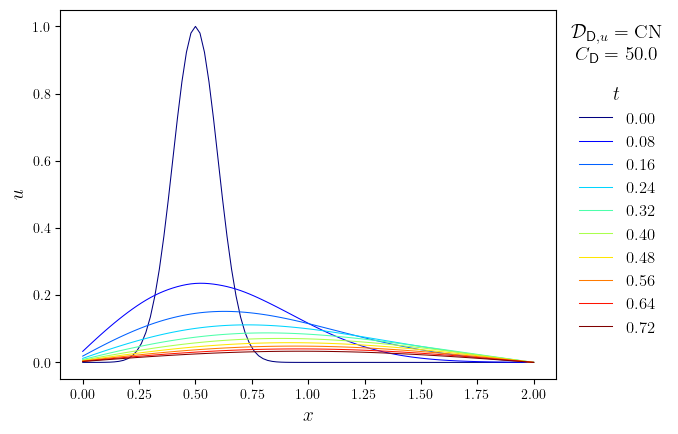

: 

In [ ]:
time_indices = as_index(u.time_series, 10, range_from_int=True)
legend_title = "\n".join(
    (
        f"$\mathcal{{D}}_{{\mathsf{{D}}, u}}=\\mathrm{{{str(D_diff)}}}$",
        f"$C_{{\mathsf{{D}}}}={courant}$",
        "\n$t$",
    )
)
legend_labels = [f'{u.time_series[i]:.2f}' for i in time_indices]
fig, ax = plot_line(
    [u.series[i] for i in time_indices], 
    legend_labels, 
    legend_title, 
    cyc='jet', x_label='$x$', y_label='$u$',
)
save_figure('u(x,t)', thumbnail=True)(fig)